In [2]:
import astropy.constants as acon
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
import astropy.constants as acon
from helper import *

In [3]:
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel

# One or many times
t = Time("2013-06-22 00:00:00")  # or Time(np.linspace(...), format='jd') for an array

pos, vel = get_body_barycentric_posvel('earth', t)

# pos, vel are CartesianRepresentation in ICRS frame (barycentric)
r_xyz = pos.xyz.to('km')        # position vector, [x, y, z]
v_xyz = vel.xyz.to('km/s')      # velocity vector, [vx, vy, vz]

In [4]:
pos_earth, vel_earth = get_body_barycentric_posvel('earth', t)
pos_sun, vel_sun     = get_body_barycentric_posvel('sun', t)

r_helio = pos_earth - pos_sun     # Earth position relative to Sun
v_helio = vel_earth - vel_sun     # Earth velocity relative to Sun (this is V_⊕(t) in the paper)

In [5]:
from astropy.coordinates import HeliocentricMeanEcliptic, SkyCoord

coord = SkyCoord(pos_earth, frame='icrs', representation_type='cartesian', obstime=t)
ecl = coord.transform_to(HeliocentricMeanEcliptic(obstime=t))

In [6]:
from vel_conversions import *

In [7]:
from scipy.optimize import minimize
import astropy.constants as acon

def grav(x):
    '''
    Returns potential at a certain distance from the Sun
    @param x The distance from the Sun, in kilometres.
    '''
    return - acon.G.value * 1e-9 * acon.M_sun.value / x

def jacobian_closed_form(u, Phi, theta):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    #v = np.asarray(v, dtype=float)
    v = np.sqrt(u*u + 2*Phi)
    vdotr = v * np.cos(theta)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)

def theta_inf(theta, u, Phi):
    v = np.sqrt(u*u + 2 * Phi)
    numer = v * np.sin(theta) * (u - v * np.cos(theta))
    denom = u * v * np.cos(theta) - (v*np.cos(theta))**2 + Phi
    tan = numer/denom
    
    angle = np.arctan(tan)
    if angle < 0:
        angle = np.pi + angle
        
    return angle

def func(theta, u, Phi, thetainf):
    return np.abs(theta_inf(theta, u, Phi) - thetainf)


In [8]:
t0 = Time("2013-06-22 00:00:00")

times = t0 + np.linspace(0, 50, 250) * u.day + 1 * u.day

In [9]:
site = EarthLocation(lat=51.4779 * u.deg, lon=-0.0015 * u.deg, height=45 * u.m)
start  = sun_to_lab_position(t0, site, frame="ecliptic")
res = sun_to_lab_position(times, site, frame="ecliptic")

In [10]:
spd = 220

vel_str = (spd * start[0] / start[1]).value
vlab = res[2].value.T
speed = res[3].value
r = res[0].value.T
dist = res[1].value
theta = np.sum(vel_str * r, axis=1) / dist / np.linalg.norm(vel_str)
theta = np.arccos(theta)
Phi = -grav(dist)

spd_loc = np.sqrt(spd*spd + 2 * Phi)

#v_loc = 220 * np.array((np.cos(theta), np.sin(theta), np.zeros_like(theta))).T - vlab

In [11]:
from scipy.spatial.transform import Rotation

def rotationz(t):
    return np.row_stack(([np.cos(t), -np.sin(t), 0],
                     [np.sin(t), np.cos(t), 0],
                     [0, 0, 1]))

def rotationy(t):
    return np.row_stack(([np.cos(t), 0, np.sin(t)],
                     [0, 1, 0],
                     [-np.sin(t), 0, np.cos(t)]))

In [12]:
dens = []
vloc1 = []
vloc2 = []
dens1 = []
dens2 = []
for i in range(theta.shape[0]):
    spd = np.linalg.norm(vel_str)
    spd_loc = np.sqrt(spd*spd + 2 * Phi[i])
    p = theta[i]
    ang1 = minimize(func, x0 = np.arccos(spd/spd_loc), bounds = [(np.arccos(spd/spd_loc), np.pi)], args=(spd, Phi[i], p)).x[0]
    ang2 = minimize(func, x0 = 0, bounds = [(0,np.arccos(spd/spd_loc))], args=(spd, Phi[i], np.pi - p)).x[0]
    
    assert func(ang1, spd, Phi[i], p) < 1e-6
    assert func(ang2, spd, Phi[i], np.pi - p) < 1e-6

    v_loc = spd_loc * rotationz(ang1) @ r[i] / dist[i] - vlab[i]
    vloc1.append(np.linalg.norm(v_loc))

    v_loc = spd_loc * rotationz(-ang2) @ r[i] / dist[i] - vlab[i]
    vloc2.append(np.linalg.norm(v_loc))

    dens1.append(1 / jacobian_closed_form(spd, Phi[i], ang1))
    dens2.append(1 / jacobian_closed_form(spd, Phi[i], ang2))
    
    #den = 1 / jacobian_closed_form(spd, Phi[i], ang1) + 1 / jacobian_closed_form(spd, Phi[i], ang2)

vloc1 = np.array(vloc1)
dens1 = np.array(dens1)
vloc2 = np.array(vloc2)
dens2 = np.array(dens2)

dens = dens1 + dens2


C:\Users\Shaurya\AppData\Local\Temp\ipykernel_1796\1020759291.py:4: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  return np.row_stack(([np.cos(t), -np.sin(t), 0],


Text(0.5, 0, 'Timestep')

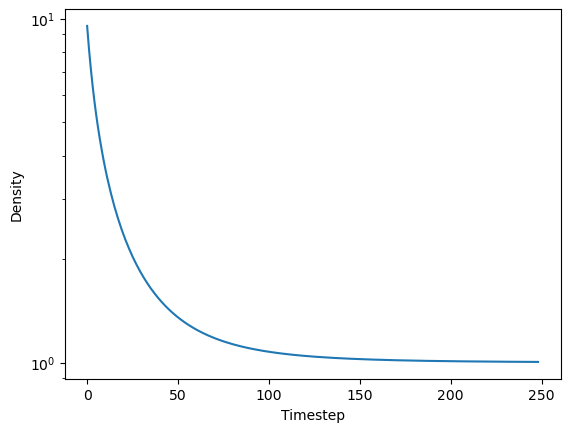

In [13]:
plt.semilogy(dens[1:])
plt.ylabel("Density")
plt.xlabel("Timestep")

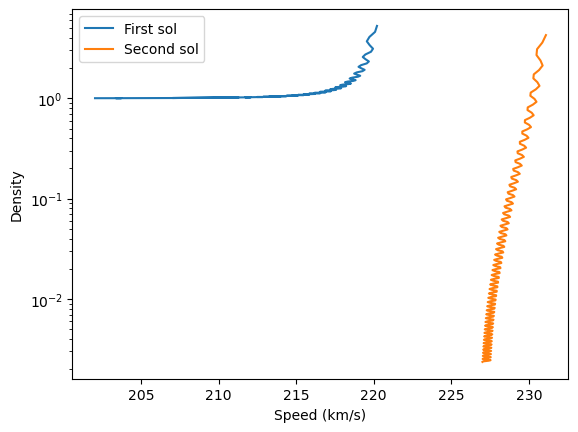

In [14]:
plt.semilogy(vloc1[1:-1], dens1[1:-1], label="First sol")
plt.semilogy(vloc2[1:-1], dens2[1:-1], label = "Second sol")
#plt.yscale("log") 
plt.xlabel("Speed (km/s)")
plt.ylabel("Density")
plt.legend()

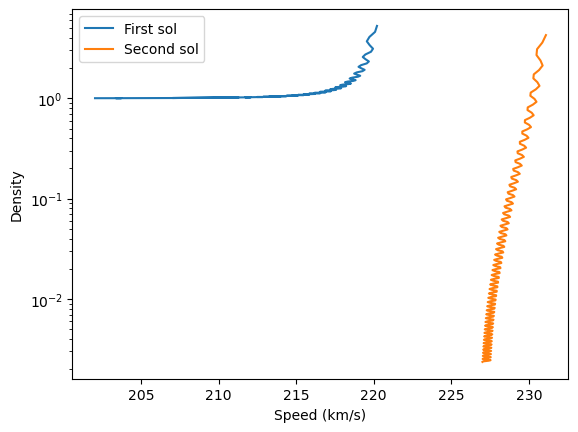

In [15]:
plt.semilogy(vloc1[1:-1], dens1[1:-1], label = "First sol")
plt.semilogy(vloc2[1:-1], dens2[1:-1], label = "Second sol")
#plt.yscale("log") 
plt.xlabel("Speed (km/s)")
plt.ylabel("Density")
plt.legend()

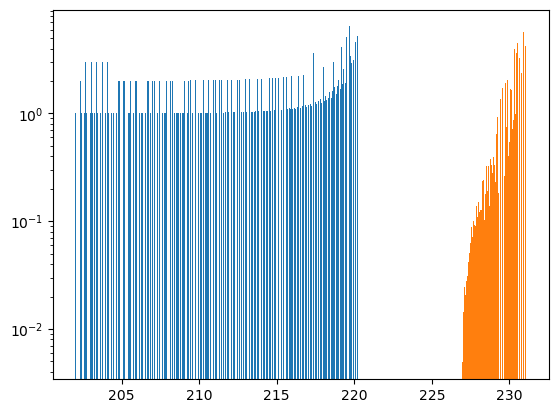

In [16]:
bins = np.linspace(np.min((vloc1, vloc2)), np.max((vloc1, vloc2)), 500)
plt.hist(vloc1[1:-1], bins, weights=dens1[1:-1])
plt.hist(vloc2[1:-1], bins, weights=dens2[1:-1])
plt.yscale('log')

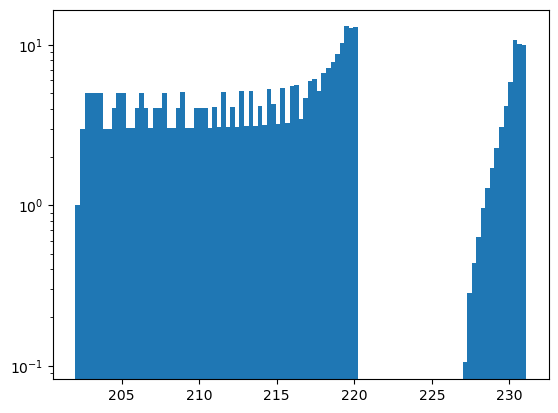

In [17]:
bins = np.linspace(np.min((vloc1, vloc2)), np.max((vloc1, vloc2)), 100)
plt.hist(np.append(vloc1[1:-1], vloc2[1:-1]), bins, weights=np.append(dens1[1:-1], dens2[1:-1]))
#plt.hist(vloc2[1:-1], bins, weights=dens2[1:-1])
plt.yscale('log')

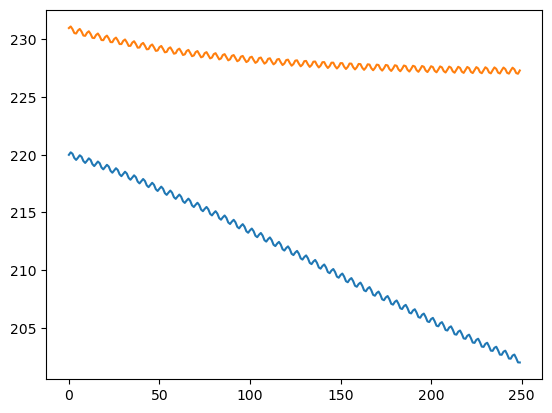

In [18]:
plt.plot(vloc1)
plt.plot(vloc2)

In [19]:
t0 = Time("2013-06-22 00:00:00") + 2 * u.day
time = t0 + 50 * u.day
site = EarthLocation(lat=51.4779 * u.deg, lon=-0.0015 * u.deg, height=45 * u.m)
start  = sun_to_lab_position(t0, site, frame="ecliptic")
res = sun_to_lab_position(time, site, frame="ecliptic")

normal = np.cross(start[0].value, res[0].value)
normal = normal / np.linalg.norm(normal)

In [20]:
t0 = Time("2013-06-22 00:00:00") + 0 * u.day
time = t0 + 2 * u.day
site = EarthLocation(lat=51.4779 * u.deg, lon=-0.0015 * u.deg, height=45 * u.m)
start  = sun_to_lab_position(t0, site, frame="ecliptic")
res = sun_to_lab_position(time, site, frame="ecliptic")


In [21]:
def rotationn(t, x):
    '''

    '''
    rot = Rotation.from_rotvec(t * normal / np.linalg.norm(normal))
    r = rot.apply(x)
    return r

def rotationr(t, x):
    '''

    '''
    normal2 = np.cross(normal, x)
    rot = Rotation.from_rotvec(t * normal2 / np.linalg.norm(normal2))
    r = rot.apply(x)

    return r

In [22]:
spd = 220

vel_str = (spd * start[0] / start[1]).value
vlab = res[2].value.T
speed = res[3].value
r = res[0].value.T
dist = res[1].value
theta = np.sum(vel_str * r) / dist / np.linalg.norm(vel_str)
theta = np.arccos(theta)
Phi = -grav(dist)

spd_loc = np.sqrt(spd*spd + 2 * Phi)

#v_loc = 220 * np.array((np.cos(theta), np.sin(theta), np.zeros_like(theta))).T - vlab

In [23]:
p = theta
ang1 = minimize(func, x0 = np.arccos(spd/spd_loc), bounds = [(np.arccos(spd/spd_loc), np.pi)], args=(spd, Phi, p)).x[0]
ang2 = minimize(func, x0 = 0, bounds = [(0,np.arccos(spd/spd_loc))], args=(spd, Phi, np.pi - p)).x[0]

In [24]:
azimuth = np.linspace(0, np.pi, 1000)
polar1 = np.pi/2 - np.arcsin(np.cos(ang1) / np.cos(azimuth))

polar2 = np.pi/2 - np.arcsin(np.cos(ang2) / np.cos(azimuth))

# do a rotation in y for polar

vloc1 = []
vloc2 = []
dens1 = []
dens2 = []
for i in range(len(azimuth)):
    #if np.isnan(polar1[i]) or np.isnan(polar2[i]): continue
    v_loc1 = spd_loc * rotationn(azimuth[i], rotationr(polar1[i], r / dist)) - vlab
    vloc1.append(np.linalg.norm(v_loc1))

    v_loc2 = spd_loc * rotationn(azimuth[i], rotationr(polar2[i], r / dist)) - vlab
    vloc2.append(np.linalg.norm(v_loc2))

    dens1.append(1 / jacobian_closed_form(spd, Phi, ang1))
    dens2.append(1 / jacobian_closed_form(spd, Phi, ang2))

vloc1 = np.array(vloc1)
dens1 = np.array(dens1) / (len(dens1) - np.isnan(polar1).sum())
vloc2 = np.array(vloc2) 
dens2 = np.array(dens2) / (len(dens2) - np.isnan(polar2).sum())

# do a rotation in z for azimuthal (rotates in x-y plane)



C:\Users\Shaurya\AppData\Local\Temp\ipykernel_1796\2030245214.py:2: RuntimeWarning: invalid value encountered in arcsin
  polar1 = np.pi/2 - np.arcsin(np.cos(ang1) / np.cos(azimuth))
C:\Users\Shaurya\AppData\Local\Temp\ipykernel_1796\2030245214.py:4: RuntimeWarning: invalid value encountered in arcsin
  polar2 = np.pi/2 - np.arcsin(np.cos(ang2) / np.cos(azimuth))


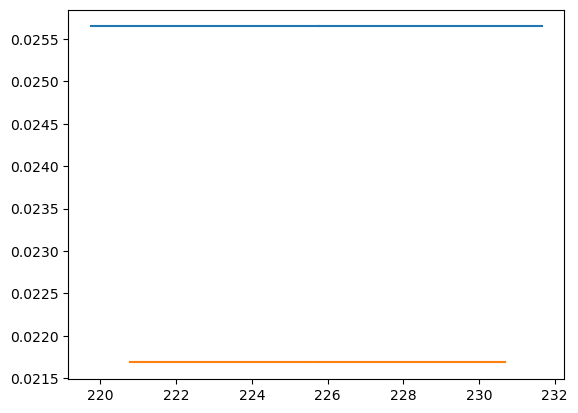

In [25]:
plt.plot(vloc1, dens1)
plt.plot(vloc2, dens2)

In [57]:


t0 = Time("2013-06-22 00:00:00") + 0 * u.day
time = t0 + (365.256363 / 2 - 0.5) * u.day
site = EarthLocation(lat=51.4779 * u.deg, lon=-0.0015 * u.deg, height=45 * u.m)
start  = sun_to_lab_position(t0, site, frame="ecliptic")


vel_str = (spd * start[0] / start[1]).value


In [81]:
bins = np.linspace(224, 228, 500)
vals = np.zeros(len(bins) - 1)

for day in np.linspace(0, 1, 100):
    res = sun_to_lab_position(time + day * u.day, site, frame="ecliptic")
    vlab = res[2].value.T
    speed = res[3].value
    r = res[0].value.T
    dist = res[1].value
    theta = np.sum(vel_str * r) / dist / np.linalg.norm(vel_str)
    theta = np.arccos(theta)
    Phi = -grav(dist)

    spd_loc = np.sqrt(spd*spd + 2 * Phi)

    p = theta
    ang1 = minimize(func, x0 = np.arccos(spd/spd_loc), bounds = [(np.arccos(spd/spd_loc), np.pi)], args=(spd, Phi, p)).x[0]
    ang2 = minimize(func, x0 = 0, bounds = [(0,np.arccos(spd/spd_loc))], args=(spd, Phi, np.pi - p)).x[0]

    azimuth = np.linspace(0, np.pi/2, 50000)
    polar1 = np.pi/2 - np.arcsin(np.cos(ang1) / np.cos(azimuth))

    polar2 = np.pi/2 - np.arcsin(np.cos(ang2) / np.cos(azimuth))

    # do a rotation in y for polar

    vloc1 = []
    vloc2 = []
    dens1 = []
    dens2 = []
    for i in range(len(azimuth)):
        #if np.isnan(polar1[i]) or np.isnan(polar2[i]): continue
        v_loc1 = spd_loc * rotationn(azimuth[i], rotationr(polar1[i], r / dist)) - vlab
        vloc1.append(np.linalg.norm(v_loc1))

        v_loc2 = spd_loc * rotationn(azimuth[i], rotationr(polar2[i], r / dist)) - vlab
        vloc2.append(np.linalg.norm(v_loc2))

        dens1.append(1 / jacobian_closed_form(spd, Phi, ang1))
        dens2.append(1 / jacobian_closed_form(spd, Phi, ang2))

    vloc1 = np.array(vloc1)
    dens1 = np.array(dens1) / (len(dens1) - np.isnan(polar1).sum())
    vloc2 = np.array(vloc2) 
    dens2 = np.array(dens2) / (len(dens2) - np.isnan(polar2).sum())

    vals += np.histogram(vloc1, bins, weights = dens1)[0]
    vals += np.histogram(vloc2, bins, weights = dens2)[0]



C:\Users\Shaurya\AppData\Local\Temp\ipykernel_1796\4058544909.py:21: RuntimeWarning: invalid value encountered in arcsin
  polar1 = np.pi/2 - np.arcsin(np.cos(ang1) / np.cos(azimuth))
C:\Users\Shaurya\AppData\Local\Temp\ipykernel_1796\4058544909.py:23: RuntimeWarning: invalid value encountered in arcsin
  polar2 = np.pi/2 - np.arcsin(np.cos(ang2) / np.cos(azimuth))


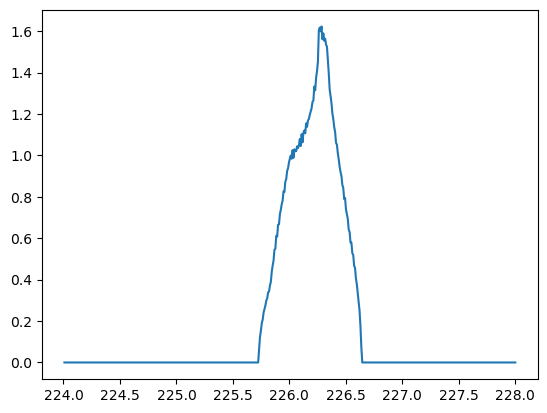

In [82]:
plt.plot(bins[1:], vals)

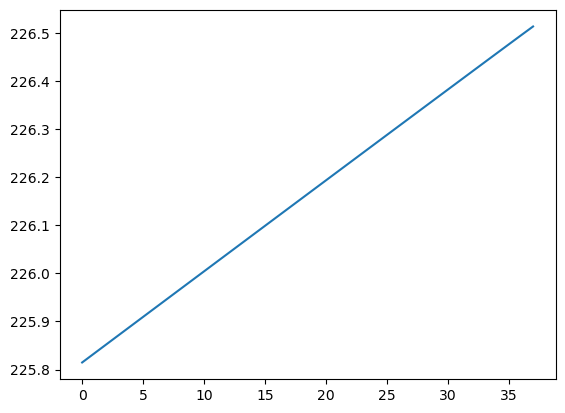

In [64]:
plt.plot(vloc1)
plt.plot(vloc2)

In [54]:
np.isnan(vloc1).sum()

np.int64(4974)